In [109]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [110]:
rawData = pd.read_excel('./data/retail_data_synthetic_50k.xlsx')

In [111]:
print(rawData.head().to_markdown())

|    | Transaction_ID   | Customer_ID   | Gender     |   Age | Category    |   Quantity |   Unit_Price |   Discount | Date                | Store_Region   | Online_Or_Offline   | Payment_Method   |   Total_Amount |
|---:|:-----------------|:--------------|:-----------|------:|:------------|-----------:|-------------:|-----------:|:--------------------|:---------------|:--------------------|:-----------------|---------------:|
|  0 | TXN-00000        | CUST-1127     | Female     |    60 | Furniture   |          9 |       202.12 |       0.26 | 2023-02-12 00:00:00 | North          | Online              | Digital Wallet   |        1346.12 |
|  1 | TXN-00001        | CUST-1460     | Male       |    30 | Beauty      |          4 |        75.03 |       0.05 | 2021-12-04 00:00:00 | West           | Online              | Digital Wallet   |         285.11 |
|  2 | TXN-00002        | CUST-0861     | Male       |    52 | Clothing    |          1 |       374.66 |       0.15 | 2020-10-21 00:00:00 | 

# Data Cleaning

In [112]:
rawData.info()
rawData.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Transaction_ID     50000 non-null  object        
 1   Customer_ID        50000 non-null  object        
 2   Gender             50000 non-null  object        
 3   Age                50000 non-null  int64         
 4   Category           50000 non-null  object        
 5   Quantity           50000 non-null  int64         
 6   Unit_Price         50000 non-null  float64       
 7   Discount           50000 non-null  float64       
 8   Date               50000 non-null  datetime64[ns]
 9   Store_Region       50000 non-null  object        
 10  Online_Or_Offline  50000 non-null  object        
 11  Payment_Method     50000 non-null  object        
 12  Total_Amount       50000 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(7)
memory 

,Age,Quantity,Unit_Price,Discount,Date,Total_Amount
count,50000.000000,50000.000000,50000.000000,50000.000000,50000,50000.000000
mean,43.425100,4.986980,252.122316,0.200063,2021-12-28 15:02:42.432000256,1004.289097
min,18.000000,1.000000,5.010000,0.000000,2020-01-01 00:00:00,3.480000
25%,30.000000,3.000000,127.837500,0.100000,2020-12-27 00:00:00,321.007500
50%,43.000000,5.000000,252.350000,0.200000,2021-12-28 00:00:00,765.855000
75%,56.000000,7.000000,375.662500,0.300000,2022-12-31 00:00:00,1488.305000
max,69.000000,9.000000,499.990000,0.400000,2023-12-31 00:00:00,4477.140000
std,15.009896,2.577119,143.094619,0.115804,NaN,845.558082


In [113]:
cleanData = rawData.copy()
cleanData.columns = [col.lower() for col in cleanData.columns]


In [114]:
mathErrors = cleanData[cleanData['total_amount'] != round(((cleanData['unit_price'] * cleanData['quantity']) - (cleanData['unit_price'] * cleanData['discount'] * cleanData['quantity'])),2)]
print(len(mathErrors))
print(mathErrors.head().to_markdown())

114
|      | transaction_id   | customer_id   | gender   |   age | category   |   quantity |   unit_price |   discount | date                | store_region   | online_or_offline   | payment_method   |   total_amount |
|-----:|:-----------------|:--------------|:---------|------:|:-----------|-----------:|-------------:|-----------:|:--------------------|:---------------|:--------------------|:-----------------|---------------:|
|  720 | TXN-00720        | CUST-0397     | Male     |    63 | Furniture  |          1 |       267.5  |       0.39 | 2021-01-30 00:00:00 | East           | In-store            | Cash             |         163.17 |
| 1121 | TXN-01121        | CUST-0542     | Male     |    48 | Grocery    |          5 |        75.77 |       0.3  | 2021-10-22 00:00:00 | South          | In-store            | Digital Wallet   |         265.19 |
| 1354 | TXN-01354        | CUST-1811     | Male     |    35 | Beauty     |          6 |       453.75 |       0.07 | 2022-11-05 00:00:00 | W

In [115]:
def checkTotal(row):
    rawTotal = row['quantity'] * row['unit_price']
    discount = rawTotal * row['discount']
    calculatedTotal = round(rawTotal - discount,2)
    difference = abs(row['total_amount'] - calculatedTotal)
    row['has_error'] = difference > .02
    return row

mathErrors = mathErrors.apply(checkTotal, axis=1)
print(f'number of records with arithmitic errors: {len(mathErrors[mathErrors['has_error']])}')

number of records with arithmitic errors: 0


# Feature Engineering

In [116]:
# Split Date field into constituant features
engDates = cleanData.copy()
engDates['year'] = engDates['date'].dt.year
engDates['month'] = engDates['date'].dt.month
engDates['day'] = engDates['date'].dt.day
engDates['day_of_week'] = engDates['date'].dt.dayofweek
engDates['quarter'] = engDates['date'].dt.quarter

dayOfWeekMap = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}

# monthMap = {
#     1: 'January',
#     2: 'February',
#     3: 'March',
#     4: 'April',
#     5: 'May',
#     6: 'June',
#     7: 'July',
#     8: 'August',
#     9: 'September',
#     10: 'October',
#     11: 'November',
#     12: 'December'
# }

# engDates['month'] = engDates['month'].map(monthMap)
engDates['day_of_week'] = engDates['day_of_week'].map(dayOfWeekMap)

print(engDates.head().to_markdown())

|    | transaction_id   | customer_id   | gender     |   age | category    |   quantity |   unit_price |   discount | date                | store_region   | online_or_offline   | payment_method   |   total_amount |   year |   month |   day | day_of_week   |   quarter |
|---:|:-----------------|:--------------|:-----------|------:|:------------|-----------:|-------------:|-----------:|:--------------------|:---------------|:--------------------|:-----------------|---------------:|-------:|--------:|------:|:--------------|----------:|
|  0 | TXN-00000        | CUST-1127     | Female     |    60 | Furniture   |          9 |       202.12 |       0.26 | 2023-02-12 00:00:00 | North          | Online              | Digital Wallet   |        1346.12 |   2023 |       2 |    12 | Sunday        |         1 |
|  1 | TXN-00001        | CUST-1460     | Male       |    30 | Beauty      |          4 |        75.03 |       0.05 | 2021-12-04 00:00:00 | West           | Online              | Digital Wal

50000
1999


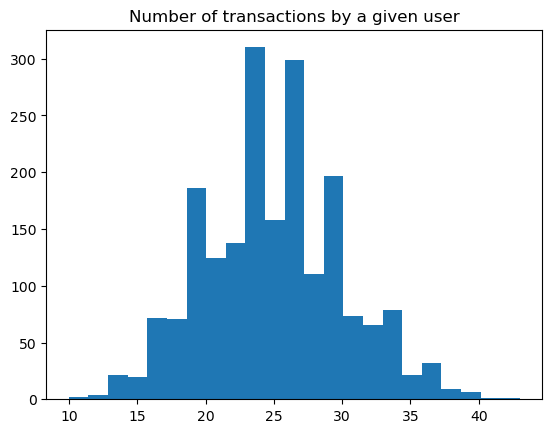

In [117]:
uniqueTransactions = engDates['transaction_id'].unique()
print(len(uniqueTransactions))

uniqueUsers = engDates['customer_id'].unique()
print(len(uniqueUsers))
# Of the 50k transactions, we have 2k users. 

byUser = engDates.groupby('customer_id')
# print(byUser['total_amount'].count().sort_values())
# Customers made anywhere from 10 to 43 purchases... plot a histogram of it.\
plt.hist(byUser['total_amount'].count().sort_values().values, bins=23)
plt.title('Number of transactions by a given user')
plt.show()

In [118]:
ageGrouped = engDates.copy()
ageBins = [18,30,40,50,60,70]
ageLabels = ['18-29','30-39','40-49','50-59','60-69']
ageGrouped['age_group'] = pd.cut(ageGrouped['age'], bins=ageBins, labels=ageLabels, right=True, include_lowest=True)

In [ ]:
# Pull the user data out: Who are the individual users, what can we say about them?

# Split users into:
# - Spending Bins
# - Online or Offline Shoppers (do specific users have a specific preference)

In [120]:
data = ageGrouped.copy()

# Visualizations

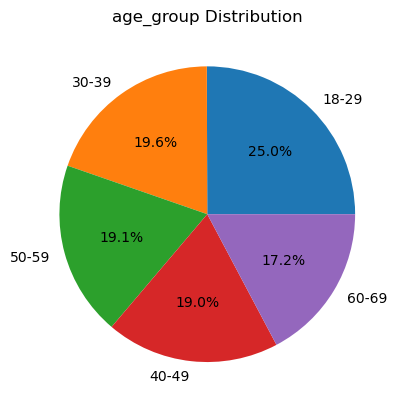

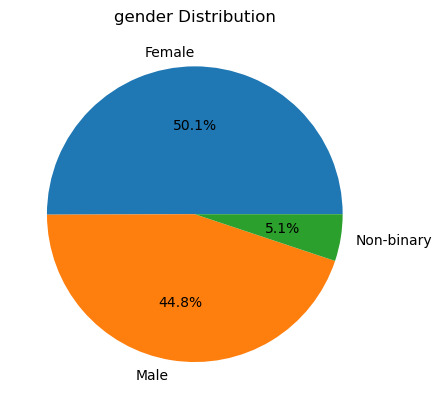

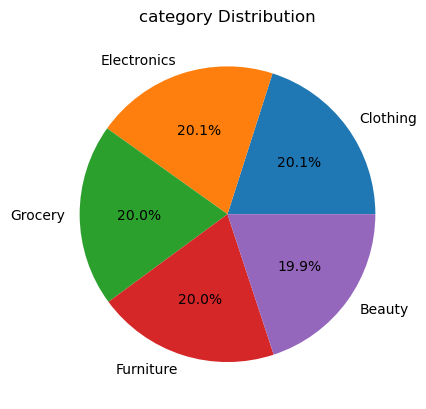

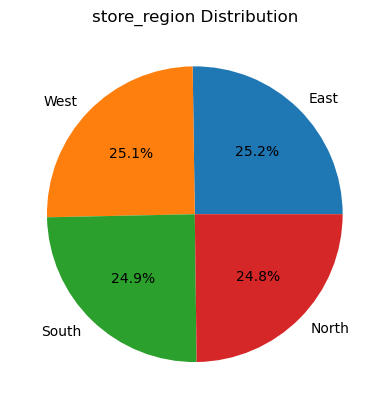

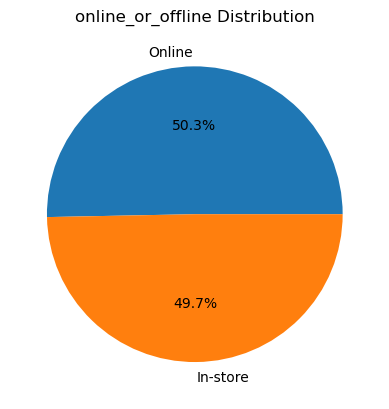

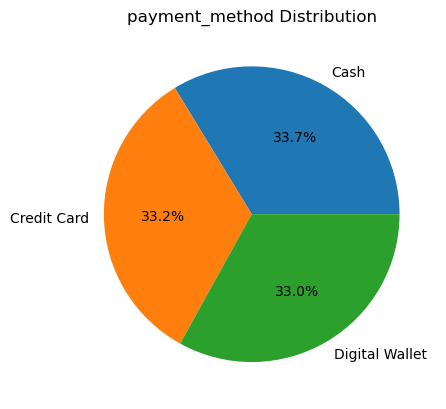

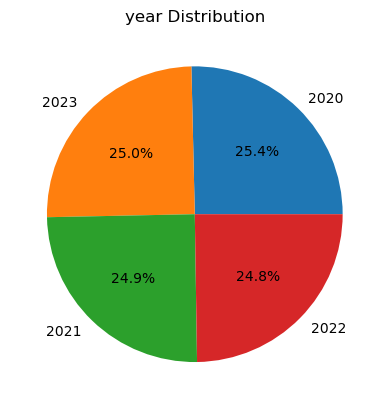

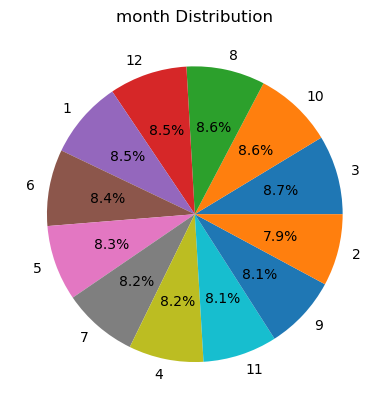

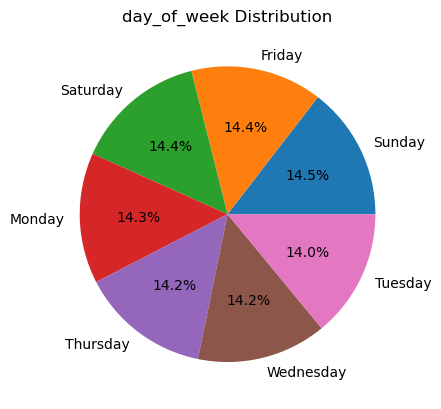

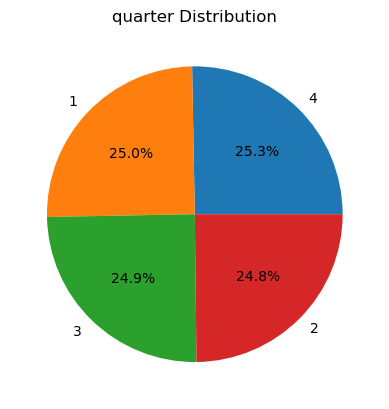

In [121]:
# Distribution of Catagorical Features
for feature in ['age_group', 'gender', 'category', 'store_region', 'online_or_offline', 'payment_method', 'year', 'month', 'day_of_week', 'quarter']:
    plt.pie(data[feature].value_counts(), labels=data[feature].value_counts().index, autopct='%1.1f%%')
    plt.title(feature + ' Distribution')
    plt.show()



<function matplotlib.pyplot.show(close=None, block=None)>

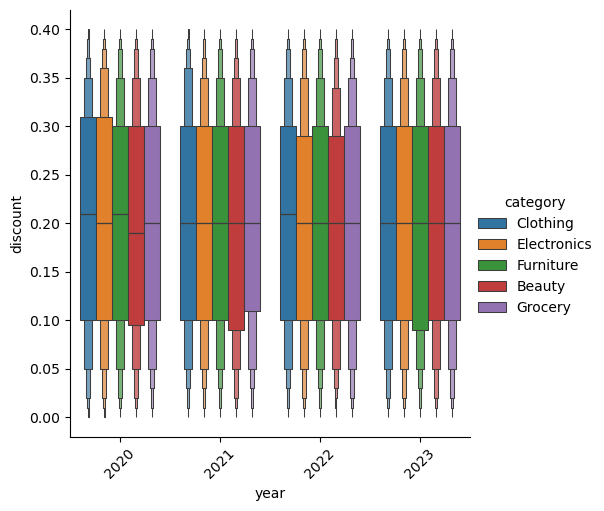

In [164]:
fig = sns.catplot(data=data, x='year', y='discount', kind="boxen", hue='category')
fig.set_xticklabels(rotation=45)
plt.show

# Time Series Analysis

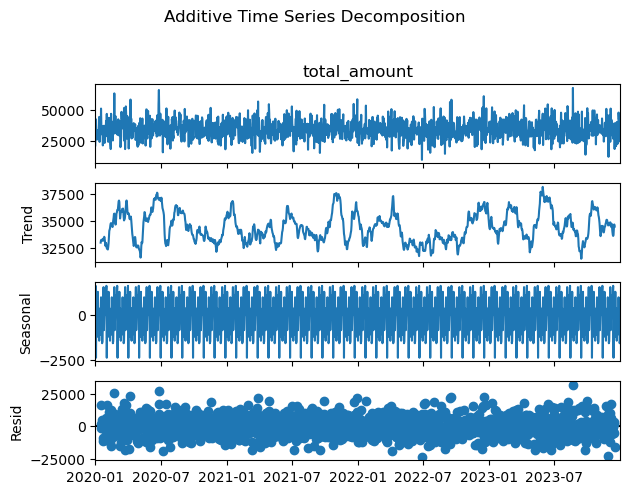

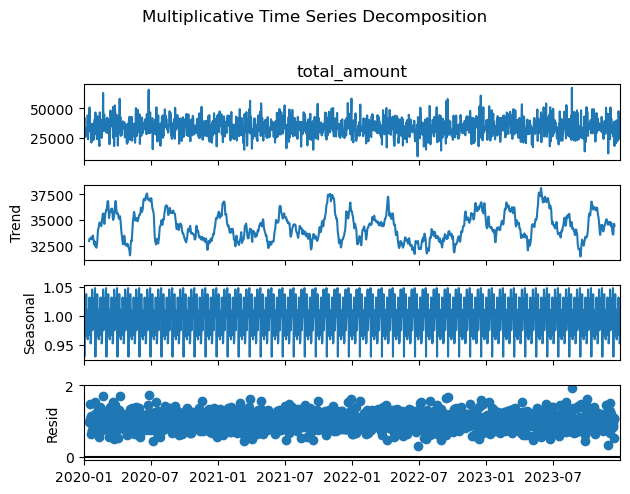

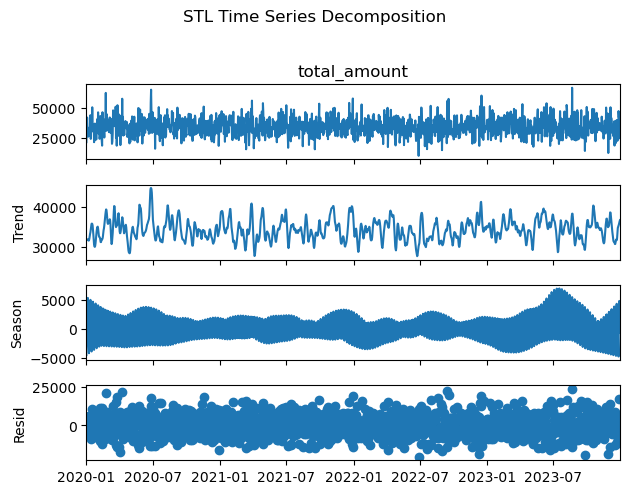

In [137]:
from statsmodels.tsa.seasonal import seasonal_decompose, STL

byDate = data.groupby('date')
# byDate = data.groupby(['year','month'])
# print(byDate['total_amount'].sum())

result_add = seasonal_decompose(byDate['total_amount'].sum(), model='additive', period=30) 
result_add.plot()
plt.suptitle('Additive Time Series Decomposition', y=1.02)
plt.tight_layout()
plt.show()

result_mul = seasonal_decompose(byDate['total_amount'].sum(), model='multiplicative', period=30)

# Plot the results
result_mul.plot()
plt.suptitle('Multiplicative Time Series Decomposition', y=1.02)
plt.tight_layout()
plt.show()

stl = STL(byDate['total_amount'].sum(), seasonal=31) 
result_stl = stl.fit()

# Plot the results
result_stl.plot()
plt.suptitle('STL Time Series Decomposition', y=1.02)
plt.tight_layout()
plt.show()



<Figure size 1000x600 with 0 Axes>

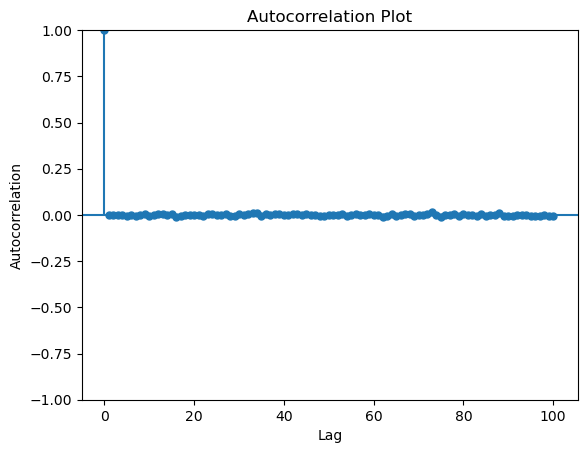

In [135]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10, 6))
plot_acf(data['total_amount'], lags=100) # 'lags' specifies the number of lags to display
plt.title('Autocorrelation Plot')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.show()